<center>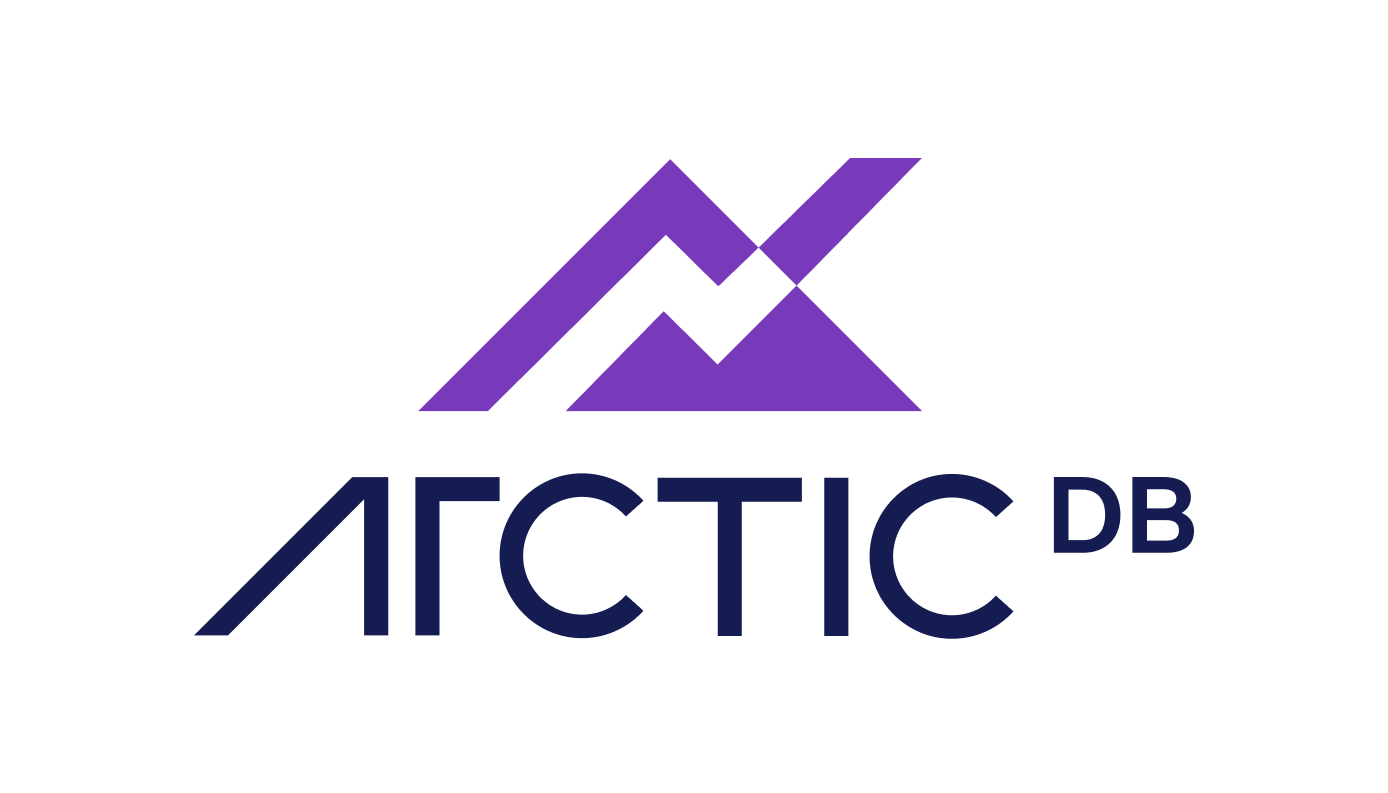
</center>

# ArcticDB Write Arrow demo

This notebook demonstrates ArcticDB's **experimental** support for writing Arrow-native data
directly: PyArrow `Table` objects and Polars `DataFrame` objects, without going through Pandas.

> **Experimental feature.** Arrow write support is still under active development and is not yet
> part of the stable public API. It must be explicitly enabled per-library (see [Setup](#Setup)
> below) using a private method, and a few capabilities described in this notebook are still
> incomplete. Sections and cells that will need to change once the feature is fully released are
> marked with **TODO**.

For details on ArcticDB's Arrow-based **read** paths (`OutputFormat.PYARROW` / `OutputFormat.POLARS`,
record batch structure on read, configurable string formats, Pandas/Arrow round-tripping) see the
companion notebook
[`ArcticDB_demo_read_as_arrow.ipynb`](ArcticDB_demo_read_as_arrow.ipynb). This notebook focuses 
on *writing* Arrow data.

**Notebook structure:**

- **Setup** - enabling experimental Arrow writes
- **Writing Polars Primitives** - `pl.DataFrame`, the `index_column` argument, and how a timeseries
  index speeds up `date_range` queries
- **Writing PyArrow Primitives** - `pa.Table`, and how record batch structure on write relates to
  storage
- **String Formats** - variable-length vs. categorical/dictionary-encoded strings
- **Pandas Interoperability** (largely a TODO - work in progress)
- **Performance Benchmarks**

# Setup

In [1]:
import timeit
from datetime import datetime

import numpy as np
import pandas as pd
import polars as pl
import pyarrow as pa

from arcticdb import Arctic, OutputFormat, ArrowOutputStringFormat
from arcticdb.exceptions import UserInputException, SchemaException, UnsortedDataException

Arrow writes are gated behind a private, underscore-prefixed method on the underlying store.
There is currently no public, stable API to opt in - this exists so we can start writing and
testing against the feature ahead of its full release.

**TODO:** remove this text section and the `lib._nvs._set_allow_arrow_input()` below when experimental label is removed as arrow writes will be accepted everywhere.

In [2]:
ac = Arctic("lmdb://tmp/arrow_writes_demo")
ac.delete_library("arrow_writes")
lib = ac.create_library("arrow_writes", output_format=OutputFormat.POLARS)

# Private/experimental toggle - not yet part of the public API.
lib._nvs._set_allow_arrow_input()

The library above is created with `output_format=OutputFormat.POLARS`, so unless a cell overrides
it explicitly, every `read` below returns a Polars object. Two kinds of cells override this default:
ones that inspect PyArrow-specific structure (record batches) need `OutputFormat.PYARROW`, and the
Pandas Interoperability section needs `OutputFormat.PANDAS` to make its point.

# Writing Polars Primitives

All writing methods like `Library.write`, `append`, `update` and `stage` accept a `pl.DataFrame` directly.

## Writing a Polars DataFrame

In [3]:
df = pl.DataFrame({
    "col_int": np.arange(10, dtype=np.int64),
    "col_float": np.arange(10, 20, dtype=np.float64),
    "col_str": [f"value_{i}" for i in range(10)],
})
lib.write("polars_basic", df)
lib.read("polars_basic").data

col_int,col_float,col_str
i64,f64,str
0,10.0,"""value_0"""
1,11.0,"""value_1"""
2,12.0,"""value_2"""
3,13.0,"""value_3"""
4,14.0,"""value_4"""
5,15.0,"""value_5"""
6,16.0,"""value_6"""
7,17.0,"""value_7"""
8,18.0,"""value_8"""


By default all arrow data is written without an index. To enable a timeseries index see below.

## The `index_column` argument

`index_column` is a **boolean** flag. When `True`, the **first column**
of the table is treated as a timeseries index. The column must:

- be the first column in the frame,
- have a timestamp dtype, and
- already be sorted in ascending order. (If `validate_index` is `True` this will be explicitly validated)

**TODO:** currently only nanosecond-precision timestamps (`pa.timestamp("ns")` / Polars
`Datetime("ns")`) are supported as an index (or indeed as any column) - other units such as
`pa.timestamp("us")` are not yet implemented.

In [4]:
ts_df = pl.DataFrame({
    "timestamp": pl.datetime_range(datetime(2025, 1, 1), datetime(2025, 1, 10), interval="1d", eager=True, time_unit="ns"),
    "value": np.arange(10, dtype=np.float64),
})
lib.write("polars_indexed", ts_df, index_column=True)
lib.read("polars_indexed").data

timestamp,value
datetime[ns],f64
2025-01-01 00:00:00,0.0
2025-01-02 00:00:00,1.0
2025-01-03 00:00:00,2.0
2025-01-04 00:00:00,3.0
2025-01-05 00:00:00,4.0
2025-01-06 00:00:00,5.0
2025-01-07 00:00:00,6.0
2025-01-08 00:00:00,7.0
2025-01-09 00:00:00,8.0


`index_column` also works with `append` and `update`. It must be passed to *every* call that
takes Arrow input - it is not remembered from the original `write`:

In [5]:
t0 = pl.DataFrame({
    "timestamp": pl.datetime_range(datetime(2025, 1, 1), datetime(2025, 1, 2), interval="1d", eager=True, time_unit="ns"),
    "value": [0.0, 1.0],
})
t1 = pl.DataFrame({
    "timestamp": pl.datetime_range(datetime(2025, 1, 3), datetime(2025, 1, 4), interval="1d", eager=True, time_unit="ns"),
    "value": [2.0, 3.0],
})
lib.write("polars_indexed_append", t0, index_column=True)
lib.append("polars_indexed_append", t1, index_column=True)
lib.read("polars_indexed_append").data

timestamp,value
datetime[ns],f64
2025-01-01 00:00:00,0.0
2025-01-02 00:00:00,1.0
2025-01-03 00:00:00,2.0
2025-01-04 00:00:00,3.0


In [6]:
t_update = pl.DataFrame({
    "timestamp": pl.datetime_range(datetime(2025, 1, 2), datetime(2025, 1, 2), interval="1d", eager=True, time_unit="ns"),
    "value": [99.0],
})
lib.update("polars_indexed_append", t_update, index_column=True)
lib.read("polars_indexed_append").data

timestamp,value
datetime[ns],f64
2025-01-01 00:00:00,0.0
2025-01-02 00:00:00,99.0
2025-01-03 00:00:00,2.0
2025-01-04 00:00:00,3.0


A few invalid uses of `index_column` and the errors they raise:

In [7]:
# First column is not a timestamp
try:
    lib.write("bad_index", pl.DataFrame({"not_a_timestamp": [1, 2, 3]}), index_column=True)
except UserInputException as e:
    print(f"UserInputException: {e}")

# No columns at all
try:
    lib.write("empty_index", pa.table({}), index_column=True)
except SchemaException as e:
    print(f"SchemaException: {e}")

# Unsorted index with validation
try:
    unsorted_df = pl.DataFrame({
        "ts": pl.Series([datetime(2025, 1, 1), datetime(2025, 1, 3), datetime(2025, 1, 2)], dtype=pl.Datetime("ns")),
    })
    lib.write("unsorted_index", unsorted_df, index_column=True, validate_index=True)
except UnsortedDataException as e:
    print(f"UnsortedDataException: {e}")

UserInputException: E_INVALID_USER_ARGUMENT Specified Arrow index column has non-time type INT64
SchemaException: E_COLUMN_DOESNT_EXIST Cannot use index_column=True on a table with no columns
UnsortedDataException: E_UNSORTED_DATA When calling write with validate_index enabled, input data must be sorted


## Performance: Using an index column allows efficient processing like `date_range` filtering

When a symbol has a timeseries index, ArcticDB allows using efficient `date_range` filter which uses the index structure.
This allows more efficient filtering than doing a similar filter in memory.

In [8]:
N = 2_000_000
timestamps = pl.datetime_range(
    pd.Timestamp("2020-01-01"),
    pd.Timestamp("2020-01-01") + pd.Timedelta(seconds=N - 1),
    interval="1s",
    eager=True,
    time_unit="ns",
)
values = np.random.randn(N)

lib.write("dr_indexed", pl.DataFrame({"ts": timestamps, "value": values}), index_column=True)
lib.write("dr_plain", pl.DataFrame({"ts": timestamps, "value": values}))

start_q = pd.Timestamp("2020-01-01") + pd.Timedelta(hours=1)
end_q = pd.Timestamp("2020-01-01") + pd.Timedelta(hours=1, minutes=5)

In [9]:
# With a timeseries index: date_range is pushed down to storage
indexed_time = timeit.timeit(
    lambda: lib.read("dr_indexed", date_range=(start_q, end_q)).data,
    number=20,
) / 20

# Without an index: read the whole symbol, then filter client-side with Polars
def read_all_then_filter():
    full = lib.read("dr_plain", output_format=OutputFormat.POLARS).data
    return full.filter((pl.col("ts") >= start_q) & (pl.col("ts") <= end_q))

plain_time = timeit.timeit(read_all_then_filter, number=20) / 20

print(f"Indexed date_range read:      {indexed_time * 1000:.2f} ms")
print(f"Unindexed read-all + filter:   {plain_time * 1000:.2f} ms")
print(f"Speedup: {plain_time / indexed_time:.1f}x")

Indexed date_range read:      5.37 ms
Unindexed read-all + filter:   209.57 ms
Speedup: 39.0x


**TODO:** `pl.Series` (a bare Polars column, without wrapping it in a single-column `pl.DataFrame`)
is not yet a supported write input - only `pl.DataFrame` and `pa.Table` are recognized by the
normalizer today.

# Writing PyArrow Primitives

`pyarrow.Table` and `pyarrow.Array` are also supported Arrow write input and works in an identical way to Polars writes.

## Writing a `pa.Table`

In [10]:
table = pa.table({
    "col_int": pa.array(np.arange(10, dtype=np.int64)),
    "col_str": pa.array([f"value_{i}" for i in range(10)]),
})
lib.write("arrow_basic", table)
lib.read("arrow_basic").data

col_int,col_str
i64,str
0,"""value_0"""
1,"""value_1"""
2,"""value_2"""
3,"""value_3"""
4,"""value_4"""
5,"""value_5"""
6,"""value_6"""
7,"""value_7"""
8,"""value_8"""


## Record Batch Structure

A `pa.Table` can be built from multiple `pa.RecordBatch` objects via `pa.Table.from_batches(...)`.
ArcticDB's on-disk row-slicing is **independent** of the input record-batch boundaries: writing
recombines the input into ArcticDB's own row-slices (by default up to ~100k rows per segment), and
reading back returns one record batch per on-disk row-slice, not one per input batch. This example
writes 3 batches of 60k rows (180k rows total) to show both effects at once: the 3 input batches
are combined, and the combined data is then resliced at the ~100k row boundary rather than at the
original 60k/120k batch boundaries.

In [11]:
N_PER_BATCH = 60_000
rb0 = pa.RecordBatch.from_arrays([pa.array(np.arange(0 * N_PER_BATCH, 1 * N_PER_BATCH))], names=["col"])
rb1 = pa.RecordBatch.from_arrays([pa.array(np.arange(1 * N_PER_BATCH, 2 * N_PER_BATCH))], names=["col"])
rb2 = pa.RecordBatch.from_arrays([pa.array(np.arange(2 * N_PER_BATCH, 3 * N_PER_BATCH))], names=["col"])
multi_batch_table = pa.Table.from_batches([rb0, rb1, rb2])
print(f"Input table has {len(multi_batch_table.to_batches())} record batches, {multi_batch_table.num_rows} rows total")

lib.write("multi_batch_input", multi_batch_table)
read_back = lib.read("multi_batch_input", output_format=OutputFormat.PYARROW).data
print(f"Read back has {len(read_back.to_batches())} record batch(es)")
assert multi_batch_table.equals(read_back)

Input table has 3 record batches, 180000 rows total
Read back has 2 record batch(es)


The same reslicing applies across separate `write`/`append` calls too - see the
[Record Batch Structure](ArcticDB_demo_read_as_arrow.ipynb) section of the read-Arrow notebook for a
full breakdown of how row-slices map to record batches on read.

**TODO:** bare `pa.Array`, `pa.ChunkedArray`, and standalone `pa.RecordBatch` objects are not yet
supported as top-level write inputs - only a `pa.Table` (or `pl.DataFrame`) is recognized. Passing
one of these directly falls through to ArcticDB's default pickling fallback rather than being
normalized as Arrow data.

# String Formats

ArcticDB accepts writing both variable length and dictionary encoded (categorical) arrow strings.

## Variable-length strings

In [12]:
strings_table = pa.table({"category": pa.array(["A", "B", "A", "B", "A"], type=pa.large_string())})
lib.write("strings_plain", strings_table)
lib.read("strings_plain").data

category
str
"""A"""
"""B"""
"""A"""
"""B"""
"""A"""


The same works via a Polars string column:

In [13]:
strings_df = pl.DataFrame({"category": ["A", "B", "A", "B", "A"]})
lib.write("strings_plain_polars", strings_df)
lib.read("strings_plain_polars").data

category
str
"""A"""
"""B"""
"""A"""
"""B"""
"""A"""


## Categorical / dictionary-encoded strings

PyArrow's `dictionary_encode()` and Polars' `pl.Categorical` dtype are both accepted. Only
`int32`/`uint32` keys over `large_string` pyarrow dictionary encodings are supported - other key/value combinations raise
a `SchemaException`.

In [14]:
dictionary_encoded = pa.array(["A", "B", "A", "B", "A"], type=pa.large_string()).dictionary_encode()
print(f"Input dtype: {dictionary_encoded.type}")

cat_table = pa.table({"category": dictionary_encoded})
lib.write("strings_categorical", cat_table)
lib.read("strings_categorical").data

Input dtype: dictionary<values=large_string, indices=int32, ordered=0>


category
str
"""A"""
"""B"""
"""A"""
"""B"""
"""A"""


Polars' native `Categorical` dtype works the same way:

In [15]:
cat_df = pl.DataFrame({"category": pl.Series(["A", "B", "A", "B", "A"], dtype=pl.Categorical)})
lib.write("strings_categorical_polars", cat_df)
lib.read("strings_categorical_polars").data.dtypes

[String]

TODO: This will change with a follow up PR

Note that by default the data reads back as plain (large) strings, not as categorical/dictionary
encoded, even though that's how it was written:

In [16]:
default_read = lib.read("strings_categorical").data
print(f"Default read-back dtype: {default_read.schema['category']}")

categorical_read = lib.read(
    "strings_categorical",
    arrow_string_format_default=ArrowOutputStringFormat.CATEGORICAL,
).data
print(f"Explicit categorical read-back dtype: {categorical_read.schema['category']}")

Default read-back dtype: String
Explicit categorical read-back dtype: Categorical


**TODO:** ArcticDB does not currently persist which string format a column was written with. To
get categorical/dictionary-encoded data back out, you must explicitly request
`ArrowOutputStringFormat.CATEGORICAL` on read (as shown above) - see the
[Configurable String Formats](ArcticDB_demo_read_as_arrow.ipynb) section of the read-Arrow notebook
for the full set of read-time options. Once the write-time format is stored, this should round-trip
automatically.

# Pandas Interoperability

**This section is a work in progress and is left mostly as a TODO.**

**TODO:** flesh this section out once Pandas/Arrow interoperability on write is finalized. At a high
level, today:

- **Write Arrow, read Pandas** - fully supported. A symbol written from a `pa.Table`/`pl.DataFrame`
  can be read back with `output_format=OutputFormat.PANDAS` (the default) and behaves like any other
  symbol.
- **Write Pandas, append/update with Arrow (or vice versa)** - **not yet supported**. Combining
  Pandas and Arrow input on the *same* symbol via `append`/`update` is expected to raise; each
  version of a symbol currently has to be written consistently from one "world" or the other. Where
  you need to combine data written from both, `arcticdb.concat` across separately-written symbols is
  the current workaround.
- **Normalization metadata** (index naming, i.e. `__index__`/`__index_level_N__`, MultiIndex
  handling, etc.) is unaffected by whether the data came from Pandas or Arrow on write - see the
  read-Arrow notebook's
  [Pandas Interoperability and Column Naming](ArcticDB_demo_read_as_arrow.ipynb) section for the
  full explanation, which applies unchanged here.

In [17]:
# Write Arrow, read back as Pandas (fully supported today)
lib.write("arrow_write_pandas_read", pa.table({"col": pa.array(np.arange(5, dtype=np.int64))}))
lib.read("arrow_write_pandas_read", output_format=OutputFormat.PANDAS).data

,col
0,0
1,1
2,2
3,3
4,4


In [18]:
# Combining Pandas and Arrow input on the same symbol is not yet supported.
lib.write("mixed_write", pd.DataFrame({"col": np.arange(3)}))
try:
    lib.append("mixed_write", pa.table({"col": pa.array([3, 4])}))
except Exception as e:
    print(f"{type(e).__name__}: {e}")

NormalizationException: E_INCOMPATIBLE_OBJECTS Append can be performed only on objects of the same type. Existing type is DataFrame new type is Arrow Table.


# Performance Benchmarks

Arrow writes have roughly the same performance as pandas for numeric types. For string types Arrow is slightly faster in general and is significantly faster if unicode characters are involved. 
On write the GIL is not required (no python strings need allocating unlike the read side), unless non-ascii characters appear in the pandas strings, then the GIL is acquired for decoding them.

## Benchmark: Numeric Data

In [19]:
df_numeric_pandas = pd.DataFrame({
    f"col_{i}": np.random.randn(1_000_000) for i in range(10)
})
df_numeric_polars = pl.from_pandas(df_numeric_pandas)

pandas_time = timeit.timeit(lambda: lib.write("bench_numeric_pandas", df_numeric_pandas), number=5) / 5
polars_time = timeit.timeit(lambda: lib.write("bench_numeric_polars", df_numeric_polars), number=5) / 5

print(f"Pandas write: {pandas_time * 1000:.1f} ms")
print(f"Polars write: {polars_time * 1000:.1f} ms")
print(f"Speedup: {pandas_time / polars_time:.2f}x")

Pandas write: 111.3 ms
Polars write: 114.0 ms
Speedup: 0.98x


## Benchmark: String Data

In [20]:
df_strings_pandas = pd.DataFrame({
    f"col_{i}": np.random.randn(200_000).astype(str) for i in range(10)
})
df_strings_polars = pl.from_pandas(df_strings_pandas)

pandas_time = timeit.timeit(lambda: lib.write("bench_strings_pandas", df_strings_pandas), number=5) / 5
polars_time = timeit.timeit(lambda: lib.write("bench_strings_polars", df_strings_polars), number=5) / 5

print(f"Pandas write: {pandas_time * 1000:.1f} ms")
print(f"Polars write: {polars_time * 1000:.1f} ms")
print(f"Speedup: {pandas_time / polars_time:.2f}x")

Pandas write: 1998.8 ms
Polars write: 1559.7 ms
Speedup: 1.28x


## Benchmark: Unicode String Data

The pandas write decodes the unicode strings via `PyUnicode_AsUTF8String` (which requires the GIL). 
Arrow/Polars strings are already UTF-8 encoded buffers, so it can work significantly faster without acquiring the GIL

In [21]:
UNICODE_POOL = np.array([f"café_日本語_données_{i}_🚀" for i in range(1000)])
df_unicode_pandas = pd.DataFrame({
    f"col_{i}": np.random.choice(UNICODE_POOL, size=200_000) for i in range(10)
})
df_unicode_polars = pl.from_pandas(df_unicode_pandas)

pandas_time = timeit.timeit(lambda: lib.write("bench_unicode_pandas", df_unicode_pandas), number=5) / 5
polars_time = timeit.timeit(lambda: lib.write("bench_unicode_polars", df_unicode_polars), number=5) / 5

print(f"Pandas write: {pandas_time * 1000:.1f} ms")
print(f"Polars write: {polars_time * 1000:.1f} ms")
print(f"Speedup: {pandas_time / polars_time:.2f}x")

Pandas write: 1271.0 ms
Polars write: 218.2 ms
Speedup: 5.83x


**TODO:** revisit these benchmarks once the feature is fully released